## Tahap 1: Problem Statement & Objectives

**Latar Belakang & Tema:**

Sejalan dengan tema *"Bridging the Gap: Empowering Future Talent through Machine Learning for Industry Innovation"*, proyek ini menunjukkan bagaimana machine learning dapat membantu pelaku bisnis retail mengambil keputusan berbasis data. Pengelola perusahaan sering kali kesulitan mengevaluasi profitabilitas ribuan produk secara manual berdasarkan laporan penjualan, untuk menentukan apakah suatu produk menguntungkan, layak dipromosikan, atau perlu dievaluasi ulang strateginya. Oleh karena itu, machine learning ini dibuat untuk membantu pengelola memprediksi profitabilitas produk secara lebih cepat dan akurat.

**Problem Statement:**

Pengelola perusahaan mengalami kesulitan dalam mengevaluasi profitabilitas ribuan produk secara manual dan satu per satu. Proses ini memakan waktu lama, sehingga keputusan penting — seperti apakah suatu produk layak dipromosikan atau perlu dievaluasi ulang strateginya — baru bisa diambil setelah waktu berlalu cukup lama. Keterlambatan ini berisiko membuat perusahaan kehilangan momentum bisnis yang tepat.

**Objectives:**
- Memprediksi rata-rata profit yang dihasilkan tiap produk berdasarkan pola order historisnya (frekuensi order, kuantitas terjual, diskon, dan rata-rata penjualan).
- Mengelompokkan produk ke dalam kategori profitable atau non-profitable untuk mendukung keputusan bisnis.

**Chosen Modelling Tasks:** Regression + Classification (keduanya pada level granularitas produk).

**Regression:**

Memprediksi rata-rata profit suatu produk, berdasarkan pola order historisnya seperti frekuensi order, total kuantitas terjual, rata-rata diskon, rata-rata penjualan (sales), dan kategori produk.

**Classification:**

Mengelompokkan produk ke dalam kategori profitable atau non-profitable, berdasarkan pola order historisnya seperti frekuensi order, total kuantitas terjual, rata-rata diskon, rata-rata penjualan (sales), serta jenis produk (category, sub_category).

## Tahap 2: Database Connection & Data Loading

Menggunakan library `sqlite3` untuk membuka koneksi ke database dan menjalankan query SQL, 
serta `pandas` untuk mengubah hasil query menjadi DataFrame yang siap diolah lebih lanjut.

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Memanggil fitur `order_key`, `product_id`, `discount`, `quantity`, `profit`, `sales`, `category`, `sub_category` dari database `superstore.sqlite` (hasil JOIN `order_items` dengan `dim_products`).

In [ ]:
conn = sqlite3.connect('superstore.sqlite')
query = """SELECT 
order_items.order_key, 
order_items.product_id, 
order_items.discount, 
order_items.quantity, 
order_items.profit, 
order_items.sales, 
dim_products.category, 
dim_products.sub_category 
FROM order_items 
join dim_products ON order_items.product_id = dim_products.product_id """
df = pd.read_sql_query(query, conn)
df.head()

Agregasi ke level produk:  
Meringkas fitur sebelumnya dari level order item (banyak baris per produk) menjadi level produk (satu baris per produk).

In [27]:
product_df = df.groupby('product_id').agg(
  total_orders = ('order_key', 'nunique'),
  avg_discount = ('discount', 'mean'),
  avg_sales = ('sales', 'mean'),
  total_quantity_sold = ('quantity', 'sum'),
  avg_profit = ('profit', 'mean'),
  category = ('category', 'first'), 
  sub_category = ('sub_category', 'first')
  ).reset_index()

product_df.head()

,product_id,total_orders,avg_discount,avg_sales,total_quantity_sold,avg_profit,category,sub_category
0,FUR-ADV-10000002,2,0.0000,79.500000,3,30.19500,Furniture,Furnishings
1,FUR-ADV-10000108,3,0.0000,116.666667,7,1.12000,Furniture,Furnishings
2,FUR-ADV-10000183,8,0.2375,121.875000,31,-81.46725,Furniture,Furnishings
3,FUR-ADV-10000188,5,0.2600,25.000000,7,0.84000,Furniture,Furnishings
4,FUR-ADV-10000190,1,0.0000,222.000000,2,104.46000,Furniture,Furnishings


## Tahap 3: Exploratory Data Analysis (EDA)

### Pemeriksaan Tipe Data dan Missing Value
Memeriksa tipe data tiap kolom menggunakan `.info()` dan mengecek jumlah nilai kosong 
(missing value) menggunakan `.isnull().sum()`.

**Hasil:** Seluruh kolom memiliki tipe data yang sesuai (kolom numerik seperti `total_orders`, 
`avg_discount`, `avg_profit` bertipe int/float, kolom kategorikal seperti `category` dan 
`sub_category` bertipe object/string), dan tidak ditemukan missing value pada seluruh kolom.

**Insight:** Karena tidak ada missing value, tidak diperlukan proses imputasi (pengisian nilai 
kosong) pada tahap preprocessing nanti — dataset sudah bersih dan siap digunakan langsung 
untuk analisis lebih lanjut.

In [28]:
product_df.info()
product_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10292 entries, 0 to 10291
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           10292 non-null  str    
 1   total_orders         10292 non-null  int64  
 2   avg_discount         10292 non-null  float64
 3   avg_sales            10292 non-null  float64
 4   total_quantity_sold  10292 non-null  int64  
 5   avg_profit           10292 non-null  float64
 6   category             10292 non-null  str    
 7   sub_category         10292 non-null  str    
dtypes: float64(3), int64(2), str(3)
memory usage: 643.4 KB


product_id             0
total_orders           0
avg_discount           0
avg_sales              0
total_quantity_sold    0
avg_profit             0
category               0
sub_category           0
dtype: int64

Melakukan pemeriksaan statistik deskriptif dasar:

Berdasarkan hasil pemeriksaan, `avg_profit` memiliki rentang yang sangat lebar, dari min -3.839,9 sampai max 5.039,9, jauh melebihi rentang kuartil 25% (-1,83) sampai 75% (37,42). Ini menandakan ada produk yang memberi keuntungan sangat besar, maupun produk yang memberi kerugian besar. Penanganan dan pemeriksaan outlier akan dilakukan menggunakan IQR pada tahap Preprocessing.

In [29]:
product_df.describe()

,total_orders,avg_discount,avg_sales,total_quantity_sold,avg_profit
count,10292.000000,10292.000000,10292.000000,10292.000000,10292.000000
mean,4.980082,0.158553,284.946613,17.325301,25.880618
std,3.405668,0.151907,517.495678,13.215248,161.536495
min,1.000000,0.000000,2.000000,1.000000,-3839.990400
25%,2.000000,0.050000,40.825000,7.000000,-1.829725
50%,4.000000,0.125000,110.666667,15.000000,8.757720
75%,7.000000,0.216667,330.031250,24.000000,37.424115
max,35.000000,0.850000,22638.000000,163.000000,5039.985600


Pemeriksaan distribusi `avg_profit` menggunakan histogram:

Berdasarkan hasil histogram, distribusinya miring ke kanan (*right-skewed*, skewness = 1,16), terlihat dari rata-rata profit (25,88) yang lebih besar dari nilai tengahnya/median (8,76). Ini menandakan mayoritas produk memiliki profit kecil mendekati 0, namun ada sejumlah kecil produk dengan profit sangat tinggi yang menarik distribusi ke kanan.

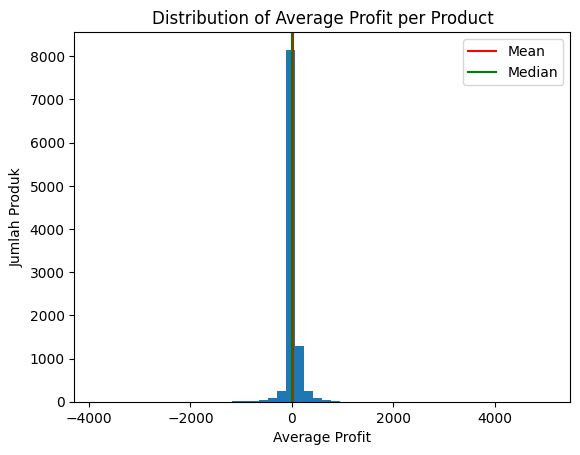

Skewness of Average Profit: 1.1571475239228886


In [30]:
import matplotlib.pyplot as plt
plt.hist(product_df['avg_profit'], bins=50)
plt.title('Distribution of Average Profit per Product')
plt.xlabel('Average Profit')
plt.ylabel('Jumlah Produk')
plt.title('Distribution of Average Profit per Product')
plt.axvline(product_df['avg_profit'].mean(), color='red', label='Mean')
plt.axvline(product_df['avg_profit'].median(), color='green', label='Median')
plt.legend()
plt.show()
print("Skewness of Average Profit:", product_df['avg_profit'].skew())


Mengecek kategori mana yang menguntungkan:

Hasil:
- Technology memiliki risiko paling tinggi dengan std: 241,4, profit rendah (min): -3.839,9 dan profit tinggi (max): 5.039,9 — Technology memiliki variasi profit yang ekstrem, bisa sangat menguntungkan atau sangat rugi.
- Office Supplies memiliki risiko paling rendah dengan std: 84,0, profit rendah (min): -1.121,6 dan profit tinggi (max): 1.477,9 — lebih tinggi dari Furniture.
- Furniture memiliki risiko menengah di antara Office Supplies dan Technology dengan std: 197,5, profit terendah (min): -1.924,5 dan profit tertinggi (max): 1.162,6 — lebih rendah dari Office Supplies.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=product_df, x='category', y='avg_profit')
plt.title('Boxplot of Average Profit by Category')
plt.show()

Pemeriksaan angka pasti dari hasil profit per kategori boxplot.

In [32]:
product_df.groupby('category')['avg_profit'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Furniture,2228.0,14.704085,197.583855,-1924.5420,-21.3825,12.044925,66.966667,1162.612500
Office Supplies,5689.0,17.333454,84.069514,-1121.6880,0.0000,6.420000,18.782350,1477.940571
Technology,2375.0,56.838990,241.469381,-3839.9904,-3.8818,28.368267,93.612960,5039.985600


Pemeriksaan heatmap untuk melihat korelasi antar variabel numerik terhadap `avg_profit`:

- `total_orders` terhadap `avg_profit` (~0,03) — jumlah pemesanan yang banyak ternyata hampir tidak berpengaruh terhadap profit.
- `total_quantity_sold` terhadap `avg_profit` (~0,05) — jumlah barang terjual yang banyak juga hampir tidak berpengaruh terhadap profit.
- `avg_discount` terhadap `avg_profit` (~-0,35) — korelasi negatif sedang, artinya diskon yang terlalu besar berasosiasi dengan profit yang lebih kecil.

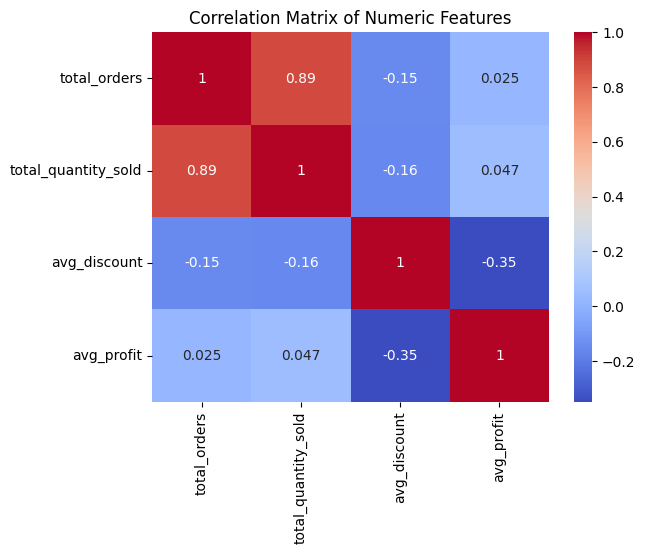

In [33]:
numeric_cols = ['total_orders', 'total_quantity_sold', 'avg_discount', 'avg_profit']
corr = product_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

Keputusan: Mempertahankan Multikolinearitas  
Ditemukan korelasi tinggi (0,885) antara `total_orders` dan `total_quantity_sold` pada tahap EDA 
(multikolinearitas). Kedua fitur tetap dipertahankan karena Random Forest relatif tahan terhadap 
multikolinearitas dibanding algoritma linear, sehingga tidak signifikan memengaruhi performa model.

Memeriksa proporsi profitable vs non-profitable pada `product_df` berdasarkan `avg_profit`:

Hasilnya 7.401 produk profitable dan 2.891 produk non-profitable. Ini menunjukkan adanya ketidakseimbangan data, di mana jumlah produk non-profitable jauh lebih sedikit dibandingkan produk profitable. Hal ini bisa membuat model kesulitan mempelajari pola produk non-profitable, sehingga perlu penanganan khusus (seperti `class_weight='balanced'`) pada tahap Classification nanti.

In [34]:
print((product_df['avg_profit'] >= 0).value_counts())

avg_profit
True     7401
False    2891
Name: count, dtype: int64


## Tahap 4: Preprocessing & Feature Engineering

Mengimpor library `train_test_split` dan membuat label profitable/non-profitable dari `avg_profit`.

In [35]:
from sklearn.model_selection import train_test_split

product_df['profitability'] = (product_df['avg_profit'] >= 0).astype(int)

Mengubah kategori menjadi numerik menggunakan one-hot encoding:  
Dikarenakan fitur kategori yang sedikit, 3 kategori dan 17 sub_category, juga akan muncul di train maupun test, risiko kebocoran data kecil.

In [36]:
product_df_encoding = pd.get_dummies(product_df, columns=['category', 'sub_category'], drop_first=True)

Memisahkan fitur (X) dan target (y):  
Alasan dibuat 2 versi karena target beda untuk task Regression dan task Classification.

In [37]:
x = product_df_encoding.drop(columns=['product_id', 'profitability', 'avg_profit'])
y_reg = product_df_encoding['avg_profit']
y_clf = product_df_encoding['profitability']

Melakukan proses `train_test_split` untuk data train dan test Regression, juga data train dan test Classification.

In [38]:
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size=0.2, random_state=42)
x_train_clf, x_test_clf, y_clf_train, y_clf_test = train_test_split(x, y_clf, test_size=0.2, random_state=42)

Untuk keputusan scaling di-skip karena menggunakan model random forest dengan cara membagi data berdasarkan threshold jadi skala fitur tidak mempengaruhi performa.

Pemeriksaan outlier:

Ditemukan sejumlah outlier yang signifikan pada `avg_profit`, yaitu 1.968 dari 10.292 produk (±19%). Outlier ini tidak dihapus/di-*capping* karena:

1. Produk dengan profit ekstrem (sangat untung/sangat rugi) merupakan insight bisnis yang paling relevan dengan tujuan project (menentukan produk mana yang perlu dievaluasi ulang strateginya).
2. Model yang digunakan adalah Random Forest, yang relatif tahan terhadap outlier dibanding algoritma linear.
3. Jika outlier dihapus atau di-*capping*, akan ada risiko kehilangan ±1/5 data produk yang justru penting untuk melakukan evaluasi ulang strategi.

In [39]:
Q1 = product_df['avg_profit'].quantile(0.25)
Q3 = product_df['avg_profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = product_df[(product_df['avg_profit'] < lower_bound) | (product_df['avg_profit'] > upper_bound)]
print("Number of outliers in avg_profit:", len(outliers))

Number of outliers in avg_profit: 1968


Pemeriksaan Data Hasil Train-Test Split:

Memeriksa ukuran data hasil `train_test_split` untuk memastikan pembagian data sudah sesuai proporsi 80:20.

Hasilnya 8.233 baris data train dan 2.059 baris data test, masing-masing dengan 22 fitur yang sama — sesuai dengan `test_size=0.2` dan menandakan tidak ada kesalahan struktur data setelah split.

In [40]:
print(x_train_reg.shape, x_test_reg.shape)
print(x_train_reg.dtypes.value_counts())
print(x_train_reg.isnull().sum().sum())  # pastikan 0

(8233, 22) (2059, 22)
bool       18
int64       2
float64     2
Name: count, dtype: int64
0


Konversi Tipe Data Boolean ke Integer  
Kolom hasil One-Hot Encoding (`category_*`, `sub_category_*`) yang awalnya bertipe boolean 
dikonversi menjadi integer (1/0) menggunakan `.astype(int)`. Konversi ini dilakukan untuk 
merapikan tipe data sekaligus mencegah potensi bug pada beberapa versi library yang kurang 
konsisten menangani tipe boolean secara langsung.

In [41]:
bool_cols = x_train_reg.select_dtypes('bool').columns

x_train_reg = x_train_reg.astype({col: 'int' for col in bool_cols})
x_test_reg = x_test_reg.astype({col: 'int' for col in bool_cols})
x_train_clf = x_train_clf.astype({col: 'int' for col in bool_cols})
x_test_clf = x_test_clf.astype({col: 'int' for col in bool_cols})

## Tahap 5: Modelling Task 1 — Regression

**Alasan pemilihan algoritma:** Random Forest Regressor dipilih karena mampu menangani fitur numerik dan kategorikal sekaligus, relatif tahan terhadap outlier dan multikolinearitas (sesuai keputusan pada tahap Preprocessing), serta dapat menangkap hubungan non-linear antar fitur yang tidak selalu terlihat dari korelasi linear biasa.

Untuk mengukur dampak fitur `avg_sales`, model dilatih dua kali: pertama tanpa `avg_sales` (baseline), lalu dengan `avg_sales` (model final), agar perbandingan "sebelum vs sesudah" dapat dibuktikan langsung dari notebook ini.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Model baseline: TANPA fitur avg_sales
x_train_reg_base = x_train_reg.drop(columns=['avg_sales'])
x_test_reg_base = x_test_reg.drop(columns=['avg_sales'])

model_reg_base = RandomForestRegressor(random_state=42)
model_reg_base.fit(x_train_reg_base, y_train_reg)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_reg_base = model_reg_base.predict(x_test_reg_base)

mae_base = mean_absolute_error(y_test_reg, y_pred_reg_base)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))
r2_base = r2_score(y_test_reg, y_pred_reg_base)

print(f"[Baseline, tanpa avg_sales] MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}, R2: {r2_base:.4f}")

[Baseline, tanpa avg_sales] MAE: 62.75, RMSE: 137.32, R2: 0.2822


**Hasil model baseline (tanpa `avg_sales`):** MAE, RMSE, dan R² di atas menjadi acuan pembanding "sebelum" untuk melihat dampak penambahan fitur `avg_sales` pada model final di bawah.

**Model final (dengan `avg_sales`):** Melatih model Random Forest Regressor menggunakan seluruh fitur, termasuk `avg_sales`.

In [42]:
from sklearn.ensemble import RandomForestRegressor

model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(x_train_reg, y_train_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Melakukan prediksi dan evaluasi pada model RandomForestRegressor (model final, dengan `avg_sales`), dibandingkan dengan model baseline (tanpa `avg_sales`):

| Metrik | Baseline (tanpa `avg_sales`) | Final (dengan `avg_sales`) |
|---|---|---|
| MAE | 62,75 | 47,34 |
| RMSE | 137,32 | 133,68 |
| R² | 0,2822 (28,22%) | 0,3198 (31,98%) |

- **MAE turun ±24,6%** (62,75 → 47,34) — rata-rata kesalahan prediksi mengecil cukup signifikan setelah `avg_sales` ditambahkan.
- **RMSE hanya turun ±2,7%** (137,32 → 133,68) — jauh lebih kecil peningkatannya dibanding MAE. Ini mengindikasikan bahwa `avg_sales` membantu memperbaiki prediksi untuk **mayoritas produk "normal"**, namun **belum banyak membantu** untuk produk dengan profit ekstrem (outlier) yang tetap dipertahankan dalam data.
- **R² naik dari 28,22% menjadi 31,98%** (naik ±4 poin persentase) — peningkatan yang nyata namun tidak drastis. Model masih belum bisa menjelaskan sebagian besar variasi profit, kemungkinan karena ada faktor lain di luar dataset (misal biaya produksi/harga pokok) yang tidak tersedia.

**Kesimpulan:** Penambahan `avg_sales` memberikan perbaikan yang terukur pada ketiga metrik, terutama pada kesalahan rata-rata (MAE), namun peningkatannya moderat — bukan lonjakan besar — dan model tetap memiliki keterbatasan dalam memprediksi produk dengan profit ekstrem.

In [43]:
y_pred_reg = model_reg.predict(x_test_reg)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 47.34256739174106
Root Mean Squared Error (RMSE): 133.68096709937717
R-squared (R2): 0.31975979001151833


Pemeriksaan Feature Importance pada model final menunjukkan bahwa `avg_sales` menjadi fitur yang paling berpengaruh terhadap prediksi `avg_profit`, dengan kontribusi sebesar 58,5%.

`avg_discount` menjadi fitur paling penting kedua sebesar 25,9%, menunjukkan diskon berpengaruh terhadap profit — konsisten dengan temuan korelasi negatif pada tahap EDA.

`total_quantity_sold` yang sebelumnya (pada model baseline) berkontribusi tinggi, turun menjadi hanya 6,1% setelah `avg_sales` ditambahkan. Ini mengindikasikan bahwa produk dengan quantity terjual tinggi biasanya juga memiliki sales yang tinggi, sehingga setelah `avg_sales` tersedia secara eksplisit, model lebih mengandalkan fitur tersebut secara langsung dibanding proxy tidak langsungnya.

Kolom-kolom hasil one-hot encoding dari `sub_category` dan `category` hanya memberi kontribusi kecil (di bawah 2%), menunjukkan bahwa jenis produk secara individual kurang berpengaruh dibanding pola perilaku transaksinya (penjualan, diskon, kuantitas).

In [44]:
importances = pd.Series(model_reg.feature_importances_, index=x_train_reg.columns)
importances.sort_values(ascending=False).head(10)

avg_sales                  0.585513
avg_discount               0.259095
total_quantity_sold        0.061282
total_orders               0.024437
sub_category_Machines      0.018515
category_Technology        0.006203
sub_category_Tables        0.006034
sub_category_Chairs        0.005608
sub_category_Appliances    0.005437
sub_category_Bookcases     0.005409
dtype: float64

## Tahap 6: Modelling Task 2 — Classification

**Alasan pemilihan algoritma:** Random Forest Classifier dipilih dengan alasan yang sama seperti Regression — mampu menangani fitur numerik dan kategorikal campuran, tahan terhadap outlier dan multikolinearitas, serta dapat menangkap hubungan non-linear antar fitur.

Memanggil library `RandomForestClassifier` dan memulai pelatihan model terhadap data train.

In [45]:
from sklearn.ensemble import RandomForestClassifier

model_clf = RandomForestClassifier(random_state=42)
model_clf.fit(x_train_clf, y_clf_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_clf = model_clf.predict(x_test_clf)

accuracy = accuracy_score(y_clf_test, y_pred_clf)
precision = precision_score(y_clf_test, y_pred_clf)
recall = recall_score(y_clf_test, y_pred_clf)
f1 = f1_score(y_clf_test, y_pred_clf)

# ROC-AUC butuh probabilitas, bukan cuma label 0/1
y_proba_clf = model_clf.predict_proba(x_test_clf)[:, 1] # ambil probabilitas kelas "1" (profitable)
roc_auc = roc_auc_score(y_clf_test, y_proba_clf)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC Score: {roc_auc}")

Accuracy: 0.78630403108305
Precision: 0.8329192546583851
Recall: 0.8869047619047619
F1 Score: 0.8590647021140295
ROC AUC Score: 0.8313062834315119


Melakukan prediksi dan evaluasi pada model RandomForestClassifier:

Hasil (metrik dihitung untuk kelas Profitable):
- **Accuracy: 78,6%** — model berhasil memprediksi profitabilitas produk secara umum (baik profitable maupun non-profitable) dengan benar pada 78,6% data test.
- **Precision: 83,3%** — dari semua produk yang diprediksi profitable, 83,3% di antaranya benar-benar profitable. Sisanya (16,7%) adalah kasus model salah menyangka produk rugi sebagai untung (false positive).
- **Recall: 88,7%** — dari semua produk yang sebenarnya profitable, model berhasil mengenali 88,7% di antaranya. Sisanya (11,3%) adalah produk yang sebenarnya profitable namun terlewat diprediksi sebagai non-profitable (false negative).
- **F1-Score: 85,9%** — nilai gabungan yang seimbang antara Precision dan Recall, menunjukkan model punya keseimbangan performa yang baik antara menghindari false positive dan false negative.
- **ROC-AUC: 83,1%** — jauh di atas 0,5 (tebak acak), menunjukkan model cukup andal dalam membedakan produk profitable dan non-profitable secara keseluruhan.

Berdasarkan hasil evaluasi, Recall (88,7%) lebih tinggi dari Precision (83,3%), artinya model lebih condong "menangkap sebanyak mungkin" produk profitable, dibanding berhati-hati soal kesalahan mengklaim.

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_clf_test, y_pred_clf, target_names=['Not Profitable', 'Profitable']))

                precision    recall  f1-score   support

Not Profitable       0.62      0.51      0.56       547
    Profitable       0.83      0.89      0.86      1512

      accuracy                           0.79      2059
     macro avg       0.73      0.70      0.71      2059
  weighted avg       0.78      0.79      0.78      2059



**Classification Report per Kelas**

Menampilkan `classification_report` untuk kelas Profitable dan Not Profitable berdasarkan Precision, Recall, dan F1-Score masing-masing kelas, tidak berdasarkan rata-rata keseluruhan seperti evaluasi sebelumnya.

Hasil: Model menunjukkan performa yang jauh lebih baik pada kelas Profitable (F1 = 0,86) dibandingkan kelas Not Profitable (F1 = 0,56). Recall pada kelas Not Profitable hanya 0,51, artinya model hanya berhasil mengenali 51% dari produk yang benar-benar merugi.

Insight: Perbedaan performa ini adalah dampak nyata dari data yang imbalance, di mana produk Not Profitable berjumlah 547 dibandingkan produk Profitable berjumlah 1.512 pada data test. Ini menjadi perhatian penting karena, secara bisnis, mendeteksi produk yang merugi justru adalah tujuan utama dari proyek ini untuk mendukung evaluasi ulang strategi.

In [ ]:
model_clf_balance = RandomForestClassifier(class_weight='balanced', random_state=42)
model_clf_balance.fit(x_train_clf, y_clf_train)

y_pred_balance = model_clf_balance.predict(x_test_clf)
y_proba_balance = model_clf_balance.predict_proba(x_test_clf)[:, 1]

print(classification_report(y_clf_test, y_pred_balance, target_names=['Not Profitable', 'Profitable']))
print(f"ROC-AUC (balanced): {roc_auc_score(y_clf_test, y_proba_balance):.4f}")

                precision    recall  f1-score   support

Not Profitable       0.64      0.52      0.57       547
    Profitable       0.84      0.89      0.86      1512

      accuracy                           0.79      2059
     macro avg       0.74      0.71      0.72      2059
  weighted avg       0.78      0.79      0.79      2059

ROC-AUC (balanced): 0.8297


Melatih ulang model dengan parameter `class_weight='balanced'`, yang memberi bobot lebih besar pada kelas Not Profitable untuk mengatasi ketidakseimbangan data saat training.

Hasil: F1-Score kelas Not Profitable naik sedikit dari 0,56 menjadi 0,57, dan Recall naik dari 0,51 menjadi 0,52. Performa kelas Profitable relatif tidak banyak berubah. ROC-AUC juga relatif tidak berubah (0,8313 → 0,8297).

Insight: Penanganan `class_weight='balanced'` memberikan sedikit perbaikan, namun tidak signifikan. Ini mengindikasikan bahwa keterbatasan utama model dalam mendeteksi produk Not Profitable kemungkinan bukan semata-mata karena imbalance data, melainkan juga karena fitur yang tersedia belum cukup membedakan karakteristik produk yang merugi secara jelas. Untuk pengembangan lebih lanjut, teknik oversampling (seperti SMOTE) atau penambahan fitur baru dapat dipertimbangkan.

**Keputusan model final:** Karena perbaikan dari `class_weight='balanced'` konsisten (meski kecil) pada kelas minoritas tanpa mengorbankan performa kelas mayoritas, **model dengan `class_weight='balanced'` (`model_clf_balance`) dipilih sebagai model final** yang akan disimpan dan digunakan pada tahap Backend API.

## Tahap 7: Conclusion & Business Insights

### 7.1 Ringkasan Problem Statement & Objectives
Sejalan dengan tema *"Bridging the Gap: Empowering Future Talent through Machine Learning for Industry Innovation"*, project ini bertujuan membantu pengelola mengevaluasi profitabilitas produk secara lebih cepat dan terukur menggunakan machine learning, dengan dua pendekatan: memprediksi rata-rata profit (**Regression**) dan mengklasifikasikan produk profitable/non-profitable (**Classification**).

### 7.2 Ringkasan Hasil Exploratory Data Analysis (EDA)
Pemeriksaan EDA pada dataset `superstore.sqlite` menemukan:

- **Distribusi profit right-skewed** (skewness = 1,16), dengan mean (25,88) jauh lebih besar dari median (8,76), menandakan mayoritas produk memiliki profit kecil namun ada sejumlah kecil produk dengan profit sangat ekstrem.
- **Kategori Technology memiliki variasi profit paling besar** (std = 241,4), dengan rentang dari **-3.839,9** (min) hingga **+5.039,9** (max) — menunjukkan produk Technology bisa sangat menguntungkan atau sangat merugikan. Outlier ini sengaja dipertahankan (tidak dihapus/di-*capping*) karena dianggap insight bisnis yang paling relevan untuk menentukan produk mana yang perlu dievaluasi ulang strateginya; menghapus atau meng-*capping*-nya berisiko menghilangkan ±1/5 data produk yang justru penting untuk evaluasi tersebut.
- **Korelasi negatif antara `avg_profit` dan `avg_discount`** (sekitar **-0,35**) — menandakan bahwa diskon yang terlalu besar berasosiasi dengan profit yang lebih kecil. Sebaliknya, `total_orders` dan `total_quantity_sold` hampir tidak berkorelasi dengan `avg_profit` (masing-masing ~0,03 dan ~0,05).
- **Ketidakseimbangan kelas**: 7.401 produk (72%) profitable dan 2.891 produk (28%) non-profitable.

### 7.3 Ringkasan Hasil Regression

| Metrik | Baseline (tanpa `avg_sales`) | Final (dengan `avg_sales`) |
|---|---|---|
| MAE | 62,75 | **47,34** |
| RMSE | 137,32 | **133,68** |
| R² | 28,22% | **31,98%** |

- **MAE turun ±24,6%**, **RMSE hanya turun ±2,7%** — perbaikan lebih terasa pada produk dengan profit "normal", sementara kesalahan pada produk dengan profit ekstrem (outlier) tidak banyak berkurang.
- **R² naik ±4 poin persentase** — peningkatan nyata namun moderat. Model masih belum bisa menjelaskan sebagian besar variasi profit, kemungkinan karena ada faktor lain di luar dataset (misal biaya produksi/harga pokok) yang tidak tersedia.
- **Feature importance**: `avg_sales` (58,5%) dan `avg_discount` (25,9%) adalah dua fitur paling berpengaruh pada model final.

### 7.4 Ringkasan Hasil Classification

| Metrik | Model Awal | Model Final (`class_weight='balanced'`) |
|---|---|---|
| Accuracy | 78,6% | 79% |
| Precision (Profitable) | 83,3% | 84% |
| Recall (Profitable) | 88,7% | 89% |
| F1 (Not Profitable) | 0,56 | **0,57** |
| Recall (Not Profitable) | 0,51 | **0,52** |
| ROC-AUC | 83,13% | 82,97% |

**Insight penting:** Model jauh lebih kuat mendeteksi produk **profitable** dibanding produk **non-profitable** — hal ini terkait dengan data yang imbalance (547 produk Not Profitable berbanding 1.512 produk Profitable pada data test). Penanganan `class_weight='balanced'` memberikan perbaikan kecil namun konsisten pada kelas minoritas tanpa mengorbankan performa kelas mayoritas, sehingga **model dengan `class_weight='balanced'` dipilih sebagai model final**. Ini menjadi perhatian penting secara bisnis, karena **mendeteksi produk yang merugi justru adalah tujuan utama** project ini untuk mendukung evaluasi ulang strategi — dan di titik inilah model masih perlu perbaikan lebih lanjut.

### 7.5 Rekomendasi Bisnis
1. **Kategori Technology perlu dievaluasi lebih lanjut** — variasi `avg_profit`-nya sangat besar, sehingga perlu identifikasi lebih rinci produk mana yang benar-benar menguntungkan dan mana yang merugi. Ini sejalan dengan tema project dalam membantu bisnis mengambil keputusan yang lebih tepat sasaran berbasis data.
2. **Kebijakan diskon perlu dikaji ulang**, mengingat korelasinya yang negatif terhadap profit.
3. **Model saat ini sebaiknya digunakan sebagai alat bantu awal (screening cepat)**, bukan pengambil keputusan akhir. Produk yang diprediksi non-profitable tetap perlu diverifikasi manual, karena recall model pada kelas ini masih rendah (52%) — artinya banyak produk yang sebenarnya rugi namun belum terdeteksi oleh model.

### 7.6 Keterbatasan & Saran Pengembangan
- Dataset tidak memiliki informasi biaya produksi/harga pokok, yang kemungkinan merupakan faktor penting yang hilang dari analisis ini.
- Data yang imbalance masih menjadi tantangan meski sudah ditangani sebagian melalui `class_weight='balanced'`.
- Saran pengembangan lanjutan: mencoba teknik oversampling seperti SMOTE, menambahkan fitur baru yang relevan, atau mencoba algoritma lain seperti XGBoost untuk meningkatkan performa model.

## Tahap 8: Menyimpan Model

Model yang sudah dilatih perlu disimpan ke file (`.pkl`) menggunakan `joblib`, agar nantinya dapat dimuat langsung oleh Backend API tanpa perlu melatih ulang model setiap kali server dijalankan (sesuai requirement guideline: *"The API loads the saved model file from the model/ folder (no retraining on startup)"*).

Model yang disimpan:
- **`model_reg`** — model Regression final (Random Forest, dengan fitur `avg_sales`)
- **`model_clf_balance`** — model Classification final (Random Forest dengan `class_weight='balanced'`)

Selain model, daftar nama kolom fitur (`x_train_reg.columns`) juga disimpan. Ini penting karena hasil One-Hot Encoding (`pd.get_dummies`) menghasilkan kolom seperti `category_Technology`, `sub_category_Tables`, dst — Backend API nanti perlu tahu persis kolom dan urutannya, supaya input baru dari pengguna bisa diformat dengan format yang sama persis seperti saat training.

In [ ]:
import joblib
import os

os.makedirs('model', exist_ok=True)

joblib.dump(model_reg, 'model/model_reg.pkl')
joblib.dump(model_clf_balance, 'model/model_clf.pkl')
joblib.dump(list(x_train_reg.columns), 'model/feature_columns.pkl')

print("Model Regression disimpan di   : model/model_reg.pkl")
print("Model Classification disimpan di: model/model_clf.pkl")
print("Daftar kolom fitur disimpan di  : model/feature_columns.pkl")
print()
print("Jumlah fitur:", len(x_train_reg.columns))
print("Daftar fitur:", list(x_train_reg.columns))

Model Regression disimpan di   : model/model_reg.pkl
Model Classification disimpan di: model/model_clf.pkl
Daftar kolom fitur disimpan di  : model/feature_columns.pkl

Jumlah fitur: 22
Daftar fitur: ['total_orders', 'avg_discount', 'avg_sales', 'total_quantity_sold', 'category_Office Supplies', 'category_Technology', 'sub_category_Appliances', 'sub_category_Art', 'sub_category_Binders', 'sub_category_Bookcases', 'sub_category_Chairs', 'sub_category_Copiers', 'sub_category_Envelopes', 'sub_category_Fasteners', 'sub_category_Furnishings', 'sub_category_Labels', 'sub_category_Machines', 'sub_category_Paper', 'sub_category_Phones', 'sub_category_Storage', 'sub_category_Supplies', 'sub_category_Tables']


**Verifikasi:** Untuk memastikan file `.pkl` tersimpan dengan benar dan dapat dimuat ulang tanpa error, dilakukan pengujian load-back sederhana di bawah.

In [ ]:
# Verifikasi: coba muat ulang model dan lakukan 1 prediksi contoh
loaded_reg = joblib.load('model/model_reg.pkl')
loaded_clf = joblib.load('model/model_clf.pkl')
loaded_cols = joblib.load('model/feature_columns.pkl')

sample = x_test_reg.iloc[[0]]
print("Contoh prediksi Regression (avg_profit):", loaded_reg.predict(sample)[0])
print("Contoh prediksi Classification (0=Not Profitable, 1=Profitable):", loaded_clf.predict(sample)[0])
print("Model berhasil dimuat ulang dan dapat digunakan untuk prediksi tanpa retraining.")

Contoh prediksi Regression (avg_profit): -11.349759928571427
Contoh prediksi Classification (0=Not Profitable, 1=Profitable): 0
Model berhasil dimuat ulang dan dapat digunakan untuk prediksi tanpa retraining.
